In [20]:
import calendar
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import xarray as xr
from matplotlib import colormaps as cmaps
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from sympy import Piecewise, integrate, symbols
from tqdm import tqdm

from functions.util import dt2cal, find_nearest, haversine, pycno, ws_integrand

In [21]:
FIG_SAVE_FMT = "png"

In [22]:
NOTEBOOK_DIR = Path().resolve()
DATA_DIR = NOTEBOOK_DIR / "../data"
FIGURES_DIR = NOTEBOOK_DIR / "../figures"
INNER_NITRATE_PATH = (
    DATA_DIR / "CE01ISSP/CE01ISSP_nitrate_binned_baseline_subtracted_2014-04-17_2023-09-17_with_dndt_resampled.nc"
)
MIDSHELF_NITRATE_PATH = (
    DATA_DIR / "CE02SHSP/CE02SHSP_nitrate_binned_baseline_subtracted_2015-03-18_2024-07-14_with_dndt_resampled.nc"
)
WIND_PATH = DATA_DIR / "NDBC_46050/46050_wind_binned_with_w5d_w8d.nc"
GEBCO_PATH = list(Path(DATA_DIR / "GEBCO/").glob("*.nc"))

In [23]:
inner_nitrate = xr.open_dataset(INNER_NITRATE_PATH)
midshelf_nitrate = xr.open_dataset(MIDSHELF_NITRATE_PATH)
wind = xr.open_dataset(WIND_PATH, decode_timedelta=True)
bathymetry = xr.open_mfdataset(GEBCO_PATH)

nhl_grid = xr.load_dataset(
    "../data/NHL_Gridded/newport_hydrographic_line_gridded_sections.nc",
)
nhl_grid = nhl_grid.squeeze()
nhl_grid = nhl_grid.where(nhl_grid.pressure > 10)
nhl_grid["meters"] = -haversine(
    nhl_grid["longitude"],
    nhl_grid["latitude"],
    -124.0590,
    nhl_grid["latitude"],
)
nhl_grid["time"] = nhl_grid["time"].dt.floor("D")

## 2 Layer Model Computation

Computes the simple model for nearshore nitrate based on a piecewise function utilizing the Sympy library and then integrates over the depth to get a mean depth averaged nitrate predicted by the model.

In [24]:
bathymetry = xr.open_mfdataset(GEBCO_PATH)
bathymetry = bathymetry.isel({"lat": find_nearest(bathymetry["lat"].values, 44.66)})
bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e6))})
topo = bathymetry["elevation"].squeeze().values
coast = bathymetry.isel({"lon": np.argmin(np.abs(topo))})


bathymetry = bathymetry.interp({"lon": np.linspace(-130, -123, int(1e4))})
topo = bathymetry["elevation"].squeeze().values
long = bathymetry.lon.values
lat = bathymetry.lat.values

meters = np.nan * np.zeros(len(long))
for i, lo in enumerate(long):
    meters[i] = haversine(long[0], lat, lo, lat) - haversine(
        long[0],
        lat,
        coast.lon.values,
        lat,
    )

long = long[meters > -100]
topo = topo[meters > -100]
meters = meters[meters > -100]

delta = 0.1  # nitracline width in meters
step = 0.1
r = 43
h = 125
Nm = 35
mod_zf = np.arange(-100, 100, 0.5)
x0 = meters[np.argmin(np.abs(long + 124.095))]
bot_depth = topo[np.argmin(np.abs(long + 124.095))]


mod_nit = np.nan * np.zeros((len(inner_nitrate.depth.values), len(mod_zf)))
mod_nda = np.nan * np.zeros(len(mod_zf))

z = symbols("z")
for i in tqdm(range(len(mod_zf))):
    dn = pycno(x0, mod_zf[i], r, h)
    n_profile = Piecewise(
        (0, z > dn),
        (Nm, z < dn),
    )
    mod_nit[:, i] = [n_profile.subs(z, val) for val in -inner_nitrate.depth.values]
    mod_nda[i] = integrate(n_profile, (z, bot_depth, 0)) / np.abs(bot_depth)

100%|██████████| 400/400 [00:06<00:00, 64.31it/s]


## NHL Fits

Determines the depth of the 25.8 $\sigma_\theta$ isopycnal as a function of cross-shelf distance for the gridded NHL data. Then fits NHL cross-shelf 25.8 $\sigma_\theta$ transects with a best fit exponential of the form $H - (Z_f-H)exp(-x/R_0)$. Also discards fits with unreasonably large R, H, or Zf.

In [25]:
hi = (nhl_grid["potential_density"] >= 25.8).argmax(dim="pressure")
lo = hi - 1  # ty:ignore[unsupported-operator]

d0 = nhl_grid["pressure"][lo]
d1 = nhl_grid["pressure"][hi]
v0 = nhl_grid["potential_density"].isel(pressure=lo)
v1 = nhl_grid["potential_density"].isel(pressure=hi)

# Slope is rise over run
slope = (d1 - d0) / (v1 - v0)
out = d0 + slope * (25.8 - v0)

# Mask points where density is all NaN
out = out.where(~nhl_grid["potential_density"].isnull().all(dim="pressure"))

# Now mask points outside density range
pycno_depth = out.where(
    (nhl_grid["potential_density"].min(dim="pressure") <= 25.8)
    & (nhl_grid["potential_density"].max(dim="pressure") >= 25.8),
)

nhl_grid["pycno_depth"] = -pycno_depth
nhl_grid = nhl_grid.where(nhl_grid["pycno_depth"].count(dim="longitude") > 40, drop=True)

In [26]:
# load NHL transects and compute distance from coastline in meters

print(f"Total number of NHL transects: {len(nhl_grid.time)}")
nhl_grid = nhl_grid.where(
    ((nhl_grid["time.month"] > 3) & (nhl_grid["time.month"] < 10)),
    drop=True,
)
print(f"Total number of summertime NHL transects: {len(nhl_grid.time)}")

# free H code
R = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))
R_err = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))
Zf = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))
Zf_err = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))
H = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))
H_err = np.nan * np.zeros(len(nhl_grid["pycno_depth"].T))


def _fit_pycno(x: np.ndarray, d: np.ndarray) -> tuple[float, float, float, float, float, float]:
    x = x[~np.isnan(d)]
    d = d[~np.isnan(d)]
    if len(d) < 20:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan
    (zf, r, h), cov = curve_fit(pycno, x, d, p0=[0, 43, 125])
    zf_err, r_err, h_err = np.sqrt(np.diag(cov))
    return zf, r, h, zf_err, r_err, h_err


# fit the pycnocline depth, slope, and height for each transect using xarray's apply_ufunc
zf, r, h, zf_err, r_err, h_err = xr.apply_ufunc(
    _fit_pycno,
    nhl_grid["meters"],
    nhl_grid["pycno_depth"],
    input_core_dims=[["longitude"], ["longitude"]],
    output_core_dims=[[], [], [], [], [], []],
    vectorize=True,
)

nhl_grid["R"] = r
nhl_grid["R_err"] = r_err
nhl_grid["Zf"] = zf
nhl_grid["Zf_err"] = zf_err
nhl_grid["H"] = h
nhl_grid["H_err"] = h_err


mask = (~np.isnan(nhl_grid.H)) & (~np.isnan(nhl_grid.R)) & (~np.isnan(nhl_grid.Zf))
mask = xr.DataArray(mask, dims=["time"], coords={"time": nhl_grid.time.values})
nhl_grid = nhl_grid.where(mask, drop=True)


fit_rmse = np.nan * np.empty(len(nhl_grid.time))
for i, t in enumerate(nhl_grid.time):
    temp = nhl_grid.sel(time=t)
    residuals = temp.pycno_depth - pycno(
        temp.meters.values,
        temp.Zf.values,
        temp.R.values,
        temp.H.values,
    )
    fit_rmse[i] = ((np.sum(residuals**2) / (residuals.size - 2)) ** 0.5).values

print(f"Total number of reasonable fits (fit_rmse < 10): {len(nhl_grid['time'].where(fit_rmse < 10))}")

Total number of NHL transects: 285
Total number of summertime NHL transects: 217
Total number of reasonable fits (fit_rmse < 10): 217


100%|██████████| 5/5 [00:12<00:00,  2.59s/it]


194

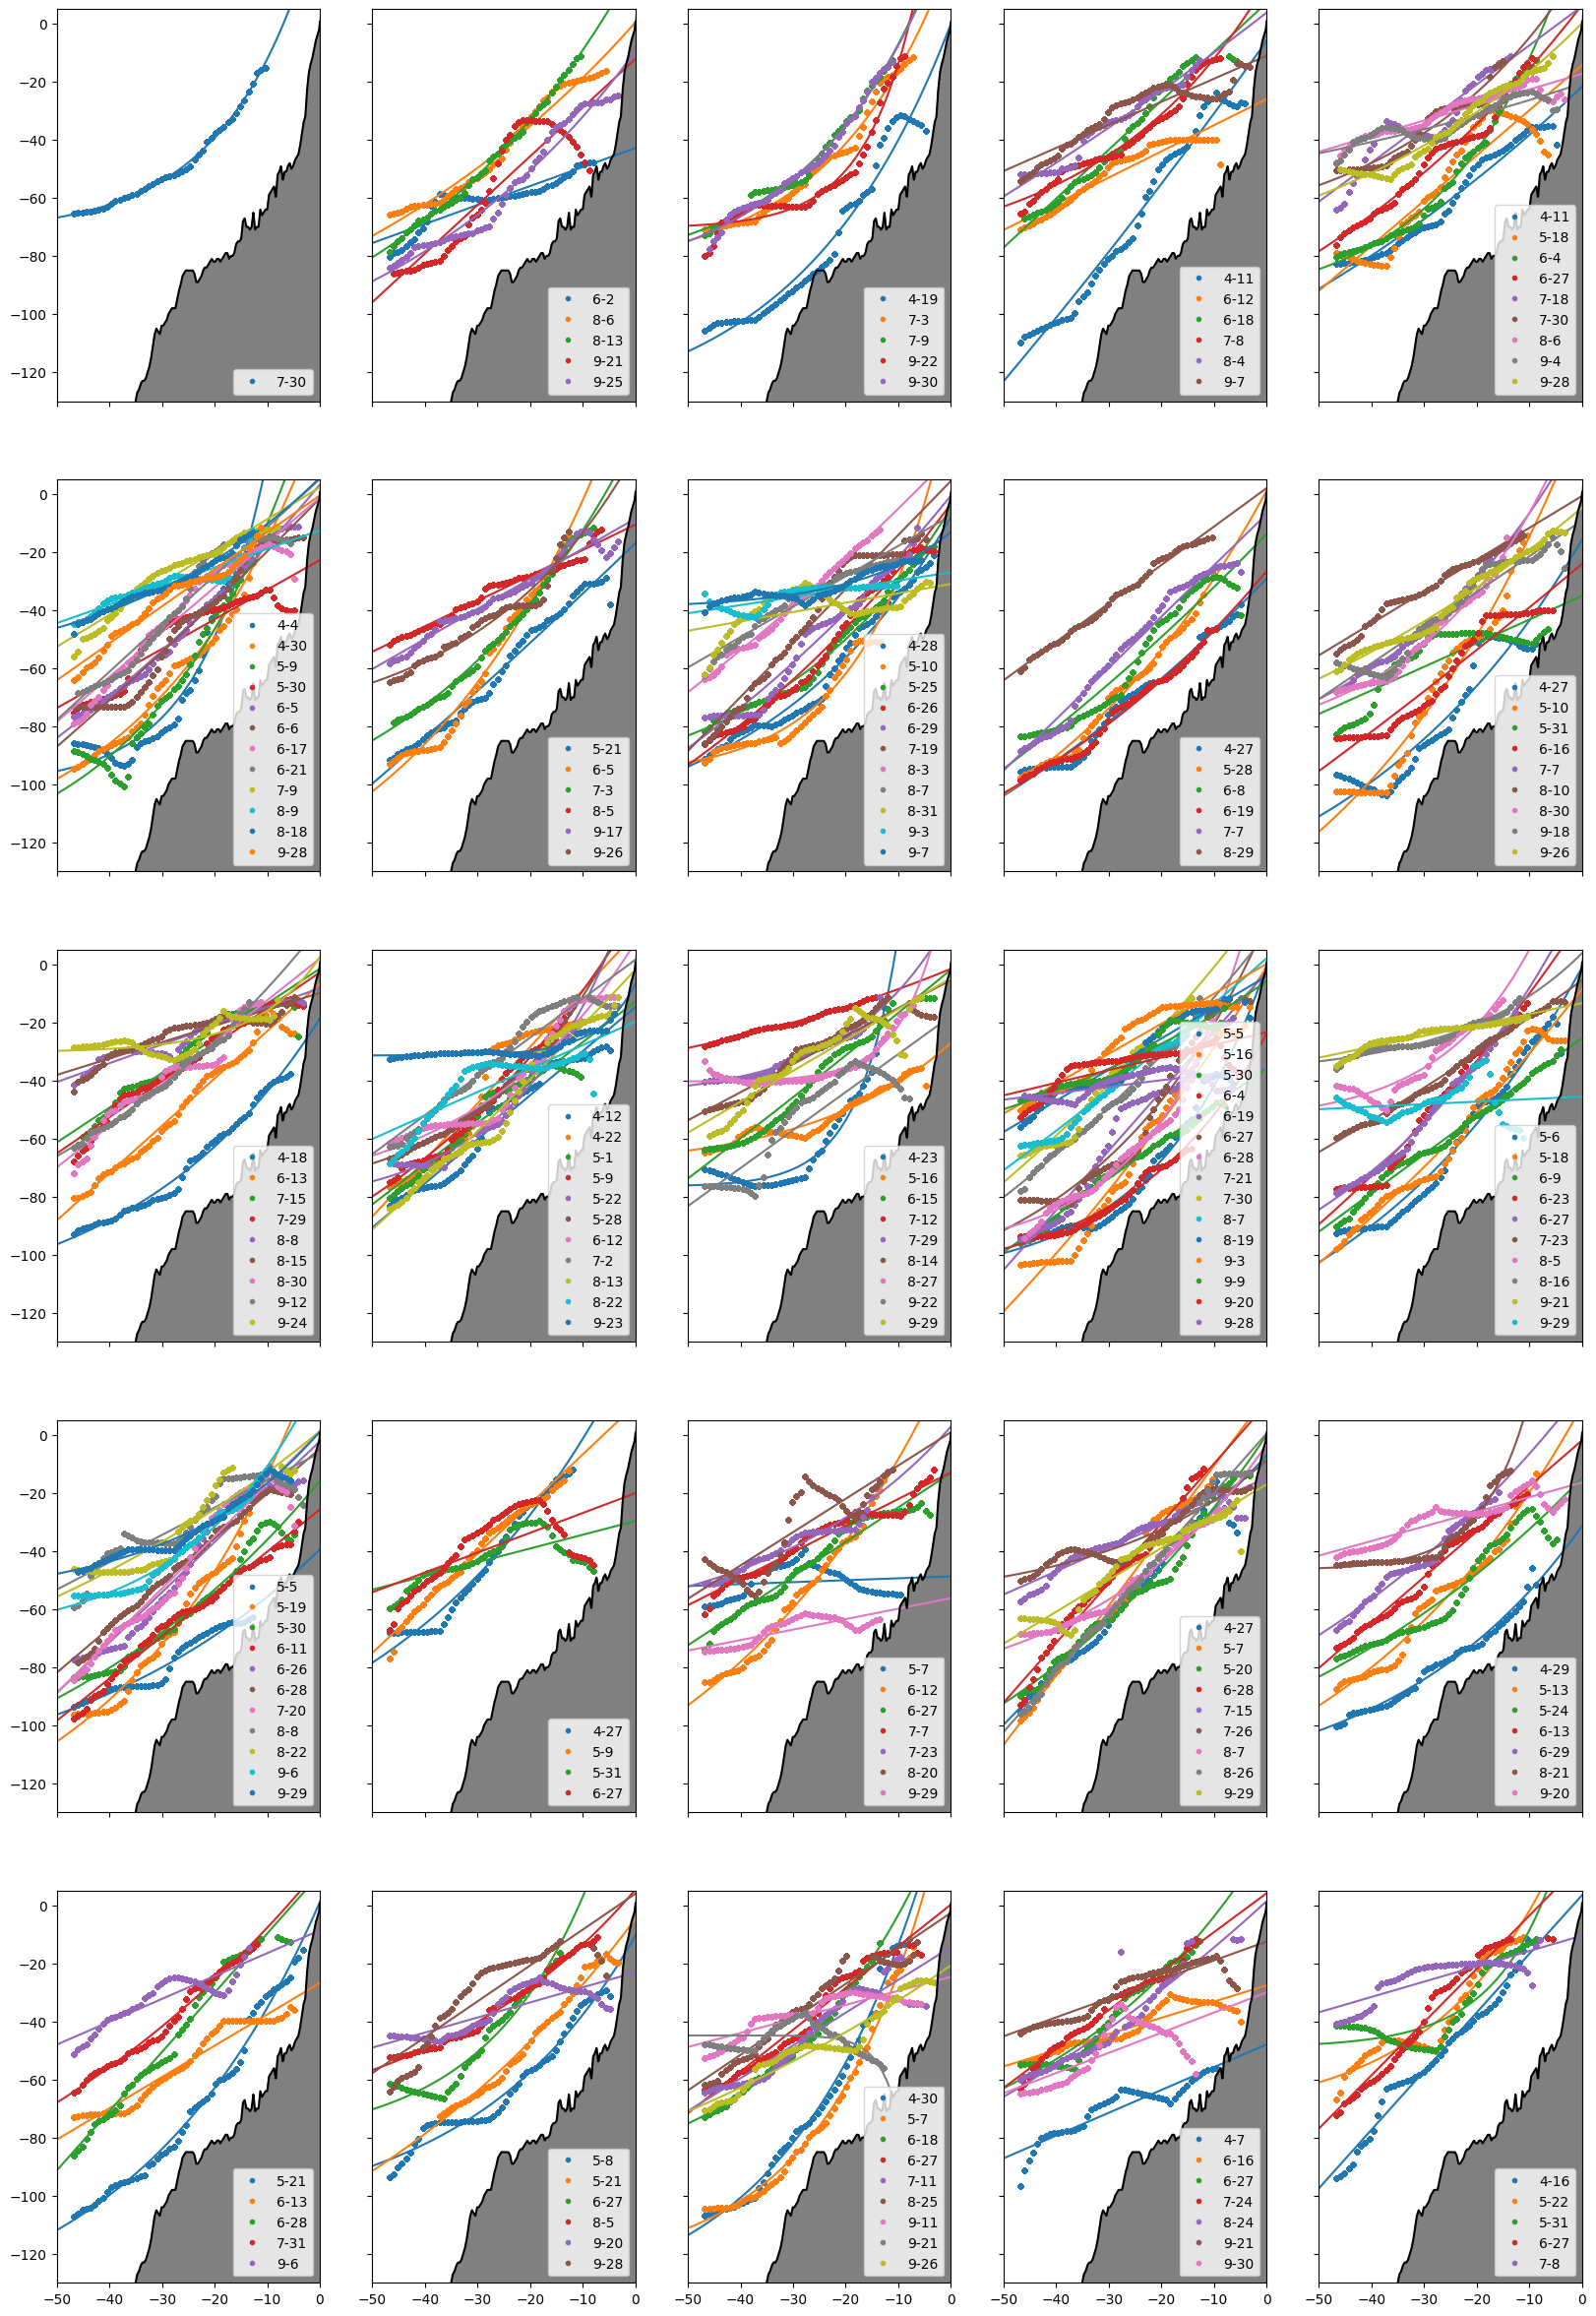

In [27]:
# plot transects and fits
col = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]
trange = np.arange(
    np.datetime64("1997"),
    np.datetime64("2022"),
    np.timedelta64(1, "Y"),
    dtype="datetime64[Y]",
)
tdelta = np.timedelta64(1, "Y")
rows = 5
cols = 5
N = 0
fig, axs = plt.subplots(5, 5, figsize=(20, 30), sharex=True, sharey=True)
for r in tqdm(range(rows)):
    for c in range(cols):
        mask = (nhl_grid["time"] >= trange[5 * r + c % 5]) & (nhl_grid["time"] < trange[5 * r + c % 5] + tdelta)
        for i, (t, d, Zf, R, H) in enumerate(
            zip(
                nhl_grid["time"][mask].values,
                nhl_grid["pycno_depth"].T[mask].values,
                nhl_grid["Zf"][mask].values,
                nhl_grid["R"][mask].values,
                nhl_grid["H"][mask].values,
                strict=False,
            ),
        ):
            mask = ~np.isnan(d) & (nhl_grid.meters.T[0] < -10)
            ymd = dt2cal(t)[0:3]
            axs[r][c].plot(
                nhl_grid["meters"],
                d,
                ".",
                label=f"{ymd[1]}-{ymd[2]}",
                c=col[i % len(col)],
            )
            axs[r][c].plot(
                np.arange(-50, 5),
                pycno(np.arange(-50, 5), Zf, R, H),
                c=col[i % len(col)],
            )
            N += 1
        # axs[r][c].annotate(ymd[0], xy=(0.1, 0.1), xycoords="axes fraction", fontsize=20)
        axs[r][c].fill_between(meters, -1000, topo, color="grey")
        axs[r][c].plot(meters, topo, color="black")
        handles, labels = axs[r][c].get_legend_handles_labels()
        by_label = dict(
            zip(labels, handles, strict=False),
        )  # dicts can't have duplicate keys, avoids duplicate legend entries
        axs[r][c].legend(by_label.values(), by_label.keys(), loc="lower right")
        axs[r][c].set_ylim([-130, 5])
        axs[r][c].set_xlim([-50, 0])
N

## Monthly mean NHL fits

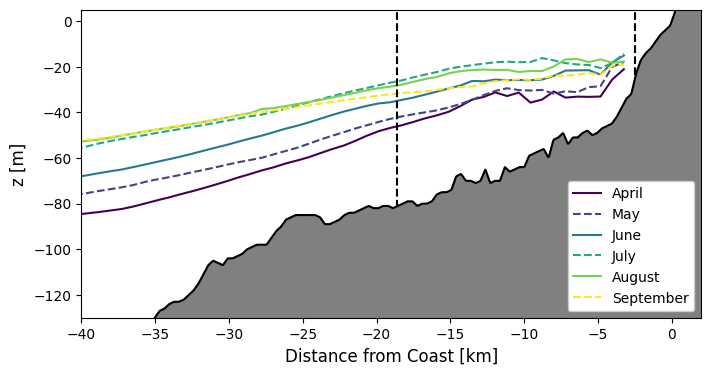

In [28]:
nhl_grid_monthly_mean = nhl_grid.groupby("time.month").mean()

fig, ax = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

# For plotting months with colormap
colors = cmaps["viridis"](np.linspace(0, 1, 6))
linestyles = ["-", "--", "-", "--", "-", "--"]

for i in range(6):
    month = i + 4
    ax.plot(
        nhl_grid_monthly_mean["meters"].sel(month=month),
        nhl_grid_monthly_mean["pycno_depth"].sel(month=month),
        label=f"{calendar.month_name[month]}",
        color=colors[i],
        linestyle=linestyles[i],
    )

ax.vlines(x0, ymin=-130, ymax=5, color="k", linestyle="--")
ax.vlines(-18.6, ymin=-130, ymax=5, color="k", linestyle="--")

ax.fill_between(meters, -1000, topo, color="grey", zorder=2)
ax.plot(meters, topo, color="black")
ax.set_xlim(-40, 2)
ax.set_ylim(-130, 5)
# ax.scatter(np.zeros(6), nhl_grid_monthly_mean["Zf"][:-1], c=colors)

plt.legend(framealpha=1)

ax.set_ylabel("z [m]", fontsize=12)
ax.set_xlabel("Distance from Coast [km]", fontsize=12)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/nhl_monthly_mean_pycno_depth.{FIG_SAVE_FMT}",
    dpi=300,
    bbox_inches="tight",
)

## Zf, R, H Time Series

R median: 40.59
H median: 126.61


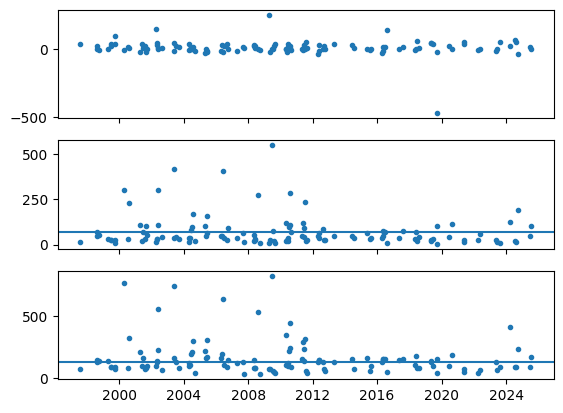

In [29]:
fig, axs = plt.subplots(3, 1, sharex=True)
mask = (
    (nhl_grid.Zf < 1000)
    & (nhl_grid.Zf > -1000)
    & (nhl_grid.R < 1000)
    & (nhl_grid.R > -1000)
    & (nhl_grid.H < 2000)
    & (fit_rmse < 10)
)
axs[0].plot(nhl_grid.time[mask], nhl_grid.Zf[mask], ".")
# axs[0].plot(nhl_grid.time, nhl_grid.Zf, '.')
# axs[0].set_ylim(-75, 125)
axs[1].plot(nhl_grid.time[mask], nhl_grid.R[mask], ".")
# axs[1].plot(nhl_grid.time, nhl_grid.R, '.')
# axs[1].set_ylim(-10, 200)
# axs[1].set_yscale('log')
axs[1].axhline(np.nanmean(nhl_grid.R[mask]))
# axs[1].axhline(np.nanmedian(nhl_grid.R))
axs[2].plot(nhl_grid.time[mask], nhl_grid.H[mask], ".")
# axs[2].plot(nhl_grid.time, nhl_grid.H, '.')
# axs[2].set_ylim(1, 2100)
# axs[2].set_yscale('log')
axs[2].axhline(np.nanmedian(nhl_grid.H[mask]))
# axs[2].axhline(np.nanmedian(nhl_grid.H))
print(f"R median: {np.nanmedian(nhl_grid.R[mask]):.2f}")
# print(f'R mean: {np.nanmedian(nhl_grid.R):.2f}')
print(f"H median: {np.nanmedian(nhl_grid.H[mask]):.2f}")
# print(f'H mean: {np.nanmedian(nhl_grid.H):.2f}')

## 25.8 Fit

Text(-54.08361745428897, -82.65268622046898, '25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data')

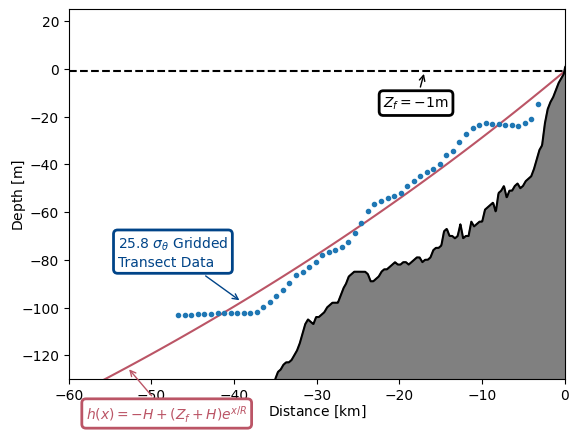

In [30]:
fig, axs = plt.subplots()
d = nhl_grid.isel(time=100)
mask = ~np.isnan(d)
axs.plot(d["meters"], d["pycno_depth"], ".")
axs.plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs.fill_between(meters, -1000, topo, color="grey")
axs.plot(meters, topo, color="black")
axs.set_ylim(-130, 25)
axs.set_xlim(-60, 0)
axs.set_xlabel("Distance [$\\mathsf{km}$]", labelpad=0)
axs.set_ylabel("Depth [$\\mathsf{m}$]", labelpad=-5)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#BB5566", "lw": 2}
axs.annotate(
    "$h(x)=-H+(Z_f+H)e^{x/R}$",
    xy=(meters[850], pycno(meters[850], d.Zf.values, d.R.values, d.H.values)),
    xytext=(meters[850] - 5, pycno(meters[850], d.Zf.values, d.R.values, d.H.values) - 15),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#BB5566"},
    color="#BB5566",
    verticalalignment="top",
)
axs.axhline(d.Zf, ls="--", color="k")
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs.annotate(
    f"$Z_f={d.Zf.values:.0f} \\mathsf{{m}}$",
    xy=(meters[1500], d.Zf.values),
    xytext=(meters[1500] - 5, d.Zf.values - 15),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#004488", "lw": 2}
axs.annotate(
    "25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data",
    xy=(meters[1100], pycno(meters[1100], d.Zf.values, d.R.values, d.H.values)),
    xytext=(meters[1100] - 15, pycno(meters[1100], d.Zf.values, d.R.values, d.H.values) + 15),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#004488"},
    color="#004488",
)
# if savefigs:
#     plt.savefig("../../figs/pycno_fit.png", dpi=600)

## Zf-Wind Fit

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.407
Model:                            WLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     89.19
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           1.94e-16
Time:                        11:44:46   Log-Likelihood:                -565.31
No. Observations:                 132   AIC:                             1135.
Df Residuals:                     130   BIC:                             1140.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -14.9393      1.440    -10.377      0.000     -17.788     -12.091
x1          -423.2016     44.811     -9.444      0.000    -511.854    -334.549
==============================================================================
Omnibus:                       10.213   Durbin-Watson:                   1.621
Prob(Omnibus):                  0.006   Jarque-Bera (JB):               15.993
Skew:                          -0.364   Prob(JB):                     0.000337
Kurtosis:                       4.542   Cond. No.                         34.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

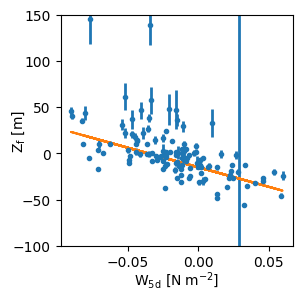

In [31]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = ((m > 3) & (m < 10)) & (fit_rmse < 10)

wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    weights=1 / nhl_al_wind["Zf_err"][mask].values,
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = {"boxstyle": "round", "fc": "w"}
wls_fit.summary()

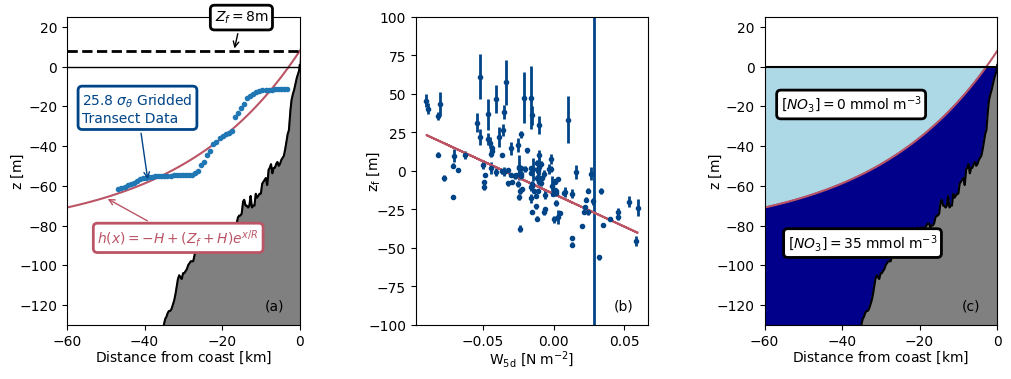

In [32]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plt.subplots_adjust(wspace=0.5)

d = nhl_grid.isel(time=85)
mask = ~np.isnan(d)
axs[0].plot(d["meters"], d["pycno_depth"], ".")
axs[0].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[0].fill_between(meters, -1000, topo, color="grey")
axs[0].plot(meters, topo, color="black")
axs[0].set_ylim([-130, 25])
axs[0].set_xlim([-60, 0])
axs[0].set_xlabel("Distance from coast [$\\mathsf{km}$]", labelpad=0)
axs[0].set_ylabel("z [$\\mathsf{{m}}$]", labelpad=-5)
axs[0].minorticks_off()
axs[0].axhline(d.Zf, ls="--", color="k", linewidth=2)
axs[0].axhline(0, color="k", linewidth=1)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#BB5566", "lw": 2}
axs[0].annotate(
    "$h(x)=-H+(Z_f+H)e^{x/R}$",
    xy=(meters[900], pycno(meters[900], d.Zf.values, d.R.values, d.H.values)),
    xytext=(meters[900] - 2, pycno(meters[900], d.Zf.values, d.R.values, d.H.values) - 15),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#BB5566"},
    color="#BB5566",
    verticalalignment="top",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[0].annotate(
    f"$Z_f={d.Zf.values:.0f} \\mathsf{{m}}$",
    xy=(meters[1500], d.Zf.values),
    xytext=(meters[1500] - 5, d.Zf.values + 15),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "#004488", "lw": 2}
axs[0].annotate(
    "25.8 $\\sigma_{\\theta}$ Gridded\nTransect Data",
    xy=(meters[1100], pycno(meters[1100], d.Zf.values, d.R.values, d.H.values)),
    xytext=(meters[1100] - 17, pycno(meters[1100], d.Zf.values, d.R.values, d.H.values) + 30),
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "#004488"},
    color="#004488",
)

# compare results below for rough estimates from AB 2002: a~=-0.85,b~=-23
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use])) & (m >= 4) & (m <= 9) & (fit_rmse < 10)
axs[1].errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
    color="#004488",
)
axs[1].plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
    color="#BB5566",
)
axs[1].set_ylim(-100, 100)
axs[1].set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
axs[1].set_ylabel("$\\mathsf{z_f}$ [$\\mathsf{m}$]", labelpad=-10)
axs[1].minorticks_off()
bbox = {"boxstyle": "round", "fc": "w"}

mask = ~np.isnan(d)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0],
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    0,
    color="lightblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0],
    -1000,
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values)[
        pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) < 0
    ],
    color="darkblue",
)
axs[2].fill_between(
    np.arange(-60, 5)[pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values) >= -1],
    -1000,
    0,
    color="darkblue",
)
axs[2].plot(
    np.arange(-60, 5),
    pycno(np.arange(-60, 5), d.Zf.values, d.R.values, d.H.values),
    zorder=1,
    c="#BB5566",
)
axs[2].fill_between(meters, -1000, topo, color="grey")
axs[2].plot(meters, topo, color="black")
axs[2].axhline(0, c="k")
axs[2].set_ylim([-130, 25])
axs[2].set_xlim([-60, 0])
axs[2].set_xlabel("Distance from coast [$\\mathsf{km}$]", labelpad=0)
axs[2].set_ylabel("z [$\\mathsf{{m}}$]", labelpad=-5)
axs[2].minorticks_off()
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[2].annotate(
    "$[NO_3]=0 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.07, 0.7),
    xytext=(0.07, 0.7),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)
bbox = {"boxstyle": "round", "fc": "w", "ec": "k", "lw": 2}
axs[2].annotate(
    "$[NO_3]=35 \\; \\mathsf{mmol \\; m^{-3}}$",
    xy=(0.1, 0.25),
    xytext=(0.1, 0.25),
    xycoords="axes fraction",
    fontsize=10,
    bbox=bbox,
    arrowprops={"arrowstyle": "->", "color": "k"},
    color="k",
)


axs[0].annotate("(a)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[1].annotate("(b)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)
axs[2].annotate("(c)", xy=(0.85, 0.05), xycoords="axes fraction", fontsize=10)

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/simple-model.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    dpi=600,
    bbox_inches="tight",
)

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     548.9
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           2.68e-91
Time:                        11:44:48   Log-Likelihood:                -2425.1
No. Observations:                 744   AIC:                             4854.
Df Residuals:                     742   BIC:                             4863.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4167      0.399     91.172      0.000      35.633      37.201
x1            -0.5002      0.021    -23.429      0.000      -0.542      -0.458
==============================================================================
Omnibus:                      117.097   Durbin-Watson:                   0.446
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              205.378
Skew:                          -0.964   Prob(JB):                     2.53e-45
Kurtosis:                       4.706   Cond. No.                         32.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

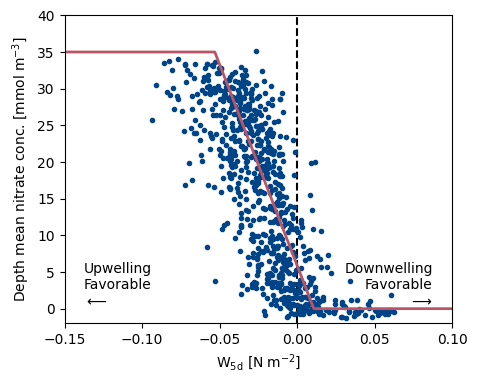

In [33]:
wind_al_nitrate, nitrate_al_wind = xr.align(wind, inner_nitrate)
slope = 1 / fit[0]
intercept = -fit[1] / fit[0]

fig, ax = plt.subplots(figsize=(5, 4))
ax.axvline(0, ls="--", color="black")
ax.plot(
    wind_al_nitrate[wind_use],
    nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True),
    ".",
    color="#004488",
)
ax.set_xlim(-0.15, 0.1)
ax.set_ylim(-2, 40)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]")
ax.set_ylabel("Depth mean nitrate conc. $[\\mathsf{mmol \\; m^{-3}}]$")
ax.plot(slope * mod_zf + intercept, mod_nda, color="#BB5566", linewidth=2)
ax.text(
    0.05,
    0.06,
    "Upwelling\nFavorable\n$\\longleftarrow$",
    transform=ax.transAxes,
    fontsize=10,
)
ax.text(
    0.95,
    0.06,
    "Downwelling\nFavorable\n$\\longrightarrow$",
    transform=ax.transAxes,
    fontsize=10,
    ha="right",
)

# computing r^2 between fit and data
xp = -slope * mod_zf + intercept
xp_idx = xp.argsort()
xp = xp[xp_idx]
mod_nda_idx = mod_nda[xp_idx]
mod_nda_interp = np.interp(wind_al_nitrate[wind_use], xp, mod_nda_idx)
mask = ~np.isnan(mod_nda_interp) & ~np.isnan(
    nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True),
)
ols_fit = sm.OLS(
    mod_nda_interp[mask],
    sm.add_constant(
        (nitrate_al_wind["nitrate"].mean(dim="depth", skipna=True)[mask]).values,
    ),
).fit()
bbox = {"boxstyle": "round", "fc": "w"}

plt.savefig(
    FIGURES_DIR / f"manuscript/{FIG_SAVE_FMT}/nitrate-wind.{FIG_SAVE_FMT}",
    format=FIG_SAVE_FMT,
    bbox_inches="tight",
    dpi=600,
)

ols_fit.summary()

In [34]:
tdelay = np.arange(1, 21)
wkd_correlation_zf = np.nan * np.zeros(tdelay.shape)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, _f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and temp.size != 0:
            fout[j] = simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
    temp = xr.Dataset(
        data_vars={"wkd": (["time"], fout)},
        coords={"time": wind["time"]},
    )
    temp_wind, temp_nhl = xr.align(temp, nhl_grid)
    m = dt2cal(temp_nhl["time"].values).T[1]
    mask = (temp_nhl["Zf"] < 100) & (temp_nhl["Zf"] > -100)
    summer = (m >= 4) & (m <= 9) & (mask) & (~np.isnan(temp_wind.wkd)) & (~np.isnan(temp_nhl.Zf))
    wkd_correlation_zf[i] = sm.tsa.stattools.ccf(
        temp_wind["wkd"][summer].values,
        temp_nhl["Zf"][summer].values,
        adjusted=True,
        nlags=1,
    )[0]

100%|██████████| 20/20 [02:15<00:00,  6.76s/it]


In [35]:
tdelay = np.arange(1, 21)
wkd_correlation_n = np.nan * np.zeros(tdelay.size)
for i, t in enumerate(tqdm(tdelay)):
    fout = np.nan * np.zeros(len(wind["day_num"]))
    for j, _f in enumerate(fout):
        temp = ws_integrand(
            wind["day_num"].values[j - t * 5 : j],
            wind["day_num"].values[j],
            wind["coare_y"].values[j - t * 5 : j],
            t,
            rho=1,
        )
        mask = ~np.isnan(temp)
        if not np.any(np.isnan(wind.coare_y[j - t * 5 : j])) and temp.size != 0:
            fout[j] = simpson(temp[mask], x=wind["day_num"].values[j - t * 5 : j][mask]) / t
    temp = xr.Dataset(
        data_vars={"wkd": (["time"], fout)},
        coords={"time": wind["time"]},
    )
    temp_nitrate, temp_wind = xr.align(
        inner_nitrate["depth_integrated_nitrate"],
        temp["wkd"],
    )
    m = dt2cal(temp_wind["time"].values).T[1]
    mask = ~np.isnan(temp_nitrate) & ~np.isnan(temp_wind)
    summer = (m >= 4) & (m <= 9) & (mask)
    wkd_correlation_n[i - 1] = sm.tsa.stattools.ccf(
        temp_nitrate[summer].values,
        temp_wind[summer].values,
        adjusted=True,
        nlags=1,
    )[0]

100%|██████████| 20/20 [02:11<00:00,  6.56s/it]


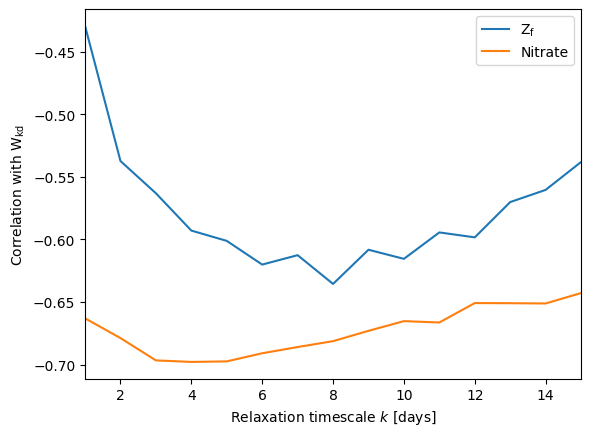

In [36]:
fig, ax = plt.subplots()
ax.plot(tdelay, wkd_correlation_zf, label="$\\mathsf{Z_f}$")
ax.plot(tdelay, wkd_correlation_n, label="Nitrate")
ax.set_xlabel("Relaxation timescale $k$ [$\\mathsf{days}$]")
ax.set_ylabel("Correlation with $\\mathsf{W_{kd}}$")
ax.legend()
ax.set_xlim(1, 15)
ax.minorticks_off()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            WLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.508
Model:                            WLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     137.5
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           3.05e-22
Time:                        11:49:15   Log-Likelihood:                -601.32
No. Observations:                 135   AIC:                             1207.
Df Residuals:                     133   BIC:                             1212.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -18.5951      1.104    -16.847      0.000     -20.778     -16.412
x1          -425.7585     36.314    -11.724      0.000    -497.586    -353.931
==============================================================================
Omnibus:                       94.600   Durbin-Watson:                   1.566
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              797.075
Skew:                          -2.366   Prob(JB):                    8.27e-174
Kurtosis:                      13.923   Cond. No.                         34.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

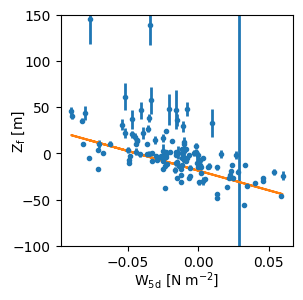

In [37]:
wind_use = "w5d"
wind_al_nhl, nhl_al_wind = xr.align(wind, nhl_grid)
m = dt2cal(nhl_al_wind["time"].values).T[1]
mask = (~np.isnan(nhl_al_wind.Zf)) & (~np.isnan(wind_al_nhl[wind_use]))
wls_fit = sm.WLS(
    nhl_al_wind["Zf"][mask].values,
    sm.add_constant(wind_al_nhl[wind_use][mask].values),
    1 / (nhl_al_wind["Zf_err"][mask].values ** 2),
    missing="drop",
).fit()
fit = wls_fit.params[::-1]
r_squared = wls_fit.rsquared

fig, ax = plt.subplots(figsize=(3, 3))
ax.errorbar(
    wind_al_nhl[wind_use][mask],
    nhl_al_wind["Zf"][mask],
    nhl_al_wind["Zf_err"][mask],
    linestyle="",
    marker=".",
    elinewidth=2,
)
ax.plot(
    wind_al_nhl[wind_use][mask],
    wind_al_nhl[wind_use][mask] * fit[0] + fit[1],
    label=f"$\\beta_0$={fit[1]:.2f}\n$\\beta_1$={fit[0]:.2f}",
)
ax.set_ylim(-100, 150)
ax.set_xlabel("$\\mathsf{W_{5d}}$ [$\\mathsf{N \\; m^{-2}}$]", labelpad=0)
ax.set_ylabel("$\\mathsf{Z_f}$ [$\\mathsf{m}$]", labelpad=-10)
bbox = {"boxstyle": "round", "fc": "w"}
wls_fit.summary()